# **Project: Used Car Price Prediction — Random Forest Regression**

## Business Problem Statement

A used-car marketplace wants to **predict the selling price** of a car based on its features
(brand, model, age, mileage, fuel type, etc.), so it can **suggest a fair price** to new sellers
based on current market conditions.

>  This is a **regression problem**: predicting a continuous value (`SellingPrice`).

## Data Collection.
* The Dataset is collected from scrapping from cardheko webiste
* The data consists of 13 column and 15411 rows.


## **1. Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV   # split data + tune hyperparameters
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## **2. Load the Dataset**

In [2]:
df = pd.read_csv(r"cardekho_imputated.csv", index_col=[0])
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## **2.1 Dataset Overview**

In [3]:
# Shape: how many rows (cars) and columns (features + target) we're working with
print("Shape:", df.shape)

# Column dtypes, non-null counts, memory footprint — quick sanity check for the whole dataframe
df.info()

Shape: (15411, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


## **(Dataset Overview)**

The dataset contains **15,411 rows** and **13 columns**, providing information about used cars and their corresponding **selling prices**.

The features can be grouped into three categories:

- **High-cardinality categorical features:** `car_name` and `model`, which contain a large number of unique values.
- **Low-cardinality categorical features:** `seller_type`, `fuel_type`, and `transmission_type`, each containing only a few distinct categories.
- **Numerical features:** `vehicle_age`, `km_driven`, `mileage`, `engine`, `max_power`, and `seats`, which describe the technical specifications and usage of each vehicle.

The **target variable** is **`selling_price`**, a continuous numerical value representing the market price of a used car. Since the target is continuous rather than categorical, this is a **supervised regression problem**.

Finally, the dataset contains **no missing values**, meaning it is already clean and ready for preprocessing and model training without requiring any imputation.

## **3. Data Cleaning**

**3.1 - Check Missing Values**

In [5]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0


## **3.2 – Remove Redundant Columns**

The dataset contains three related columns: **`car_name`**, **`brand`**, and **`model`**. These columns describe the identity of the same vehicle and therefore contain **overlapping information**.

To reduce redundancy:

- **`car_name`** is removed because it combines both the brand and model into a single text field, making it largely redundant.
- **`brand`** is removed because its information is already implicitly captured by the **`model`** column.
- **`model`** is retained because it provides the **most specific information** about a vehicle. Cars from the same brand can have very different market values depending on their model (for example, a **Maruti Alto** and a **Maruti Baleno** belong to the same brand but differ significantly in price).

Keeping only the **`model`** feature simplifies the dataset while preserving the most informative vehicle identity for predicting the **selling price**.

In [6]:
df.drop(['car_name', 'brand'], axis=1, inplace=True)
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
# Inspect how many distinct car models exist — this drives the encoding choice used later
df['model'].unique()

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

 **3.3 -  Identify Feature Types**

In [8]:
## Getting All Different Types Of Features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']       # numeric dtype columns
print('Num of Numerical Features :', len(num_features))
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']        # object/text dtype columns
print('Num of Categorical Features :', len(cat_features))
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]   # low-cardinality numeric
print('Num of Discrete Features :',len(discrete_features))
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Numerical Features : 7
Num of Categorical Features : 4
Num of Discrete Features : 2
Num of Continuous Features : 5


**Observation:** Of the 11 remaining columns (after dropping `car_name`/`brand`, still
including the target `selling_price`), **7 are numerical** (2 discrete like `seats`, 5 continuous
like `vehicle_age`, `km_driven`, `mileage`, `engine`, `max_power`, `selling_price`) and **4 are
categorical** (`model`, `seller_type`, `fuel_type`, `transmission_type`).

## **3.4 Exploratory Data Analysis (EDA)**

Before jumping into preprocessing, it's worth visually inspecting the target and the relationships
between features — this surfaces skew, outliers, and correlations that inform modeling choices
later (e.g. whether to log-transform the target, or which features are likely to matter most).

**3.4.1 Target Distribution**

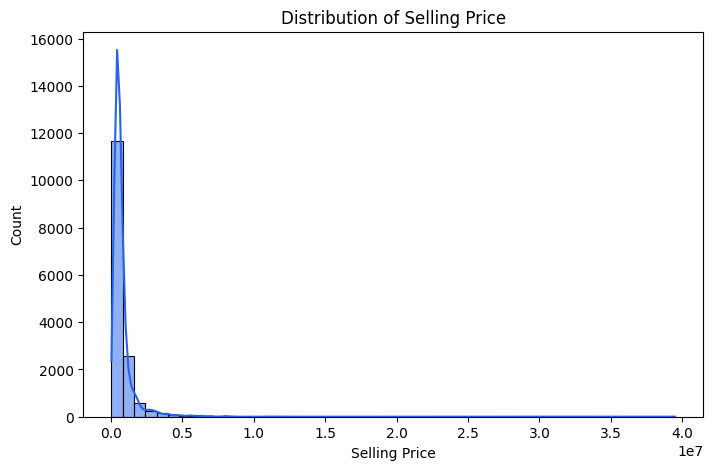

In [9]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], bins=50, kde=True, color="#2563eb")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

## **Observation (Target Distribution)**

The distribution of **`selling_price`** is **right-skewed**, meaning that **most used cars are concentrated in the lower and middle price ranges**, while a relatively small number of luxury or premium vehicles create a long tail of high prices.

This pattern is expected in the used-car market because expensive brands and models (such as **Mercedes-Benz**, **BMW**, and **Porsche**) are much less common than economy or mid-range vehicles.

The skewness of the target variable has different effects on different machine learning models:

- **Tree-based models**, such as **Decision Trees** and **Random Forests**, naturally handle skewed target distributions and generally do not require the target variable to follow a normal distribution.
- **Linear models**, such as **Linear Regression**, may be more sensitive to the long tail of expensive cars because large prediction errors on high-priced vehicles can have a greater influence on the model.

If the skewness significantly affects model performance, a common approach is to apply a **logarithmic transformation** (for example, `log(selling_price)`). This compresses the range of high prices, reduces skewness, and often improves the performance of linear regression models. After prediction, the values can be transformed back to the original price scale using the inverse transformation.

**3.4.2 Correlation Heatmap (numeric features + target)**

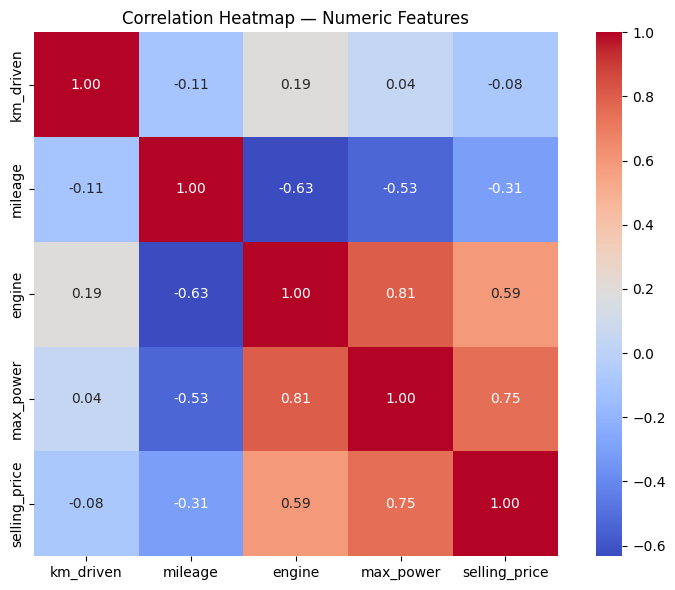

In [10]:
plt.figure(figsize=(8, 6))
corr = df[continuous_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

## **Observation (Correlation Analysis)**

The correlation matrix helps identify which **numerical features** have the strongest relationship with the target variable, **`selling_price`**, as well as the relationships among the input features themselves.

When interpreting the heatmap:

- **Positive correlation** means that as a feature increases, the **selling price tends to increase**.
- **Negative correlation** means that as a feature increases, the **selling price tends to decrease**.
- Correlation values closer to **+1** or **−1** indicate stronger relationships, while values near **0** indicate little or no linear relationship.

Typically, the following patterns are observed:

- **`max_power`** and **`engine`** show a **positive correlation** with `selling_price`, indicating that vehicles with larger engines and higher power outputs generally command higher prices.
- **`vehicle_age`** and **`km_driven`** show a **negative correlation**, meaning that older cars and vehicles with higher mileage generally have lower resale values.

The correlation matrix can also reveal relationships **between input features**. For example, **`engine`** and **`max_power`** are often highly correlated because larger engines generally produce more power.

Although highly correlated features introduce some redundancy, this is **not a major concern for Random Forest**. Tree-based models can naturally select the most informative features during training. In contrast, **linear regression models** are more sensitive to highly correlated predictors, as multicollinearity can make their coefficient estimates less stable and more difficult to interpret.

**3.4.3 Histograms of Continuous Features**

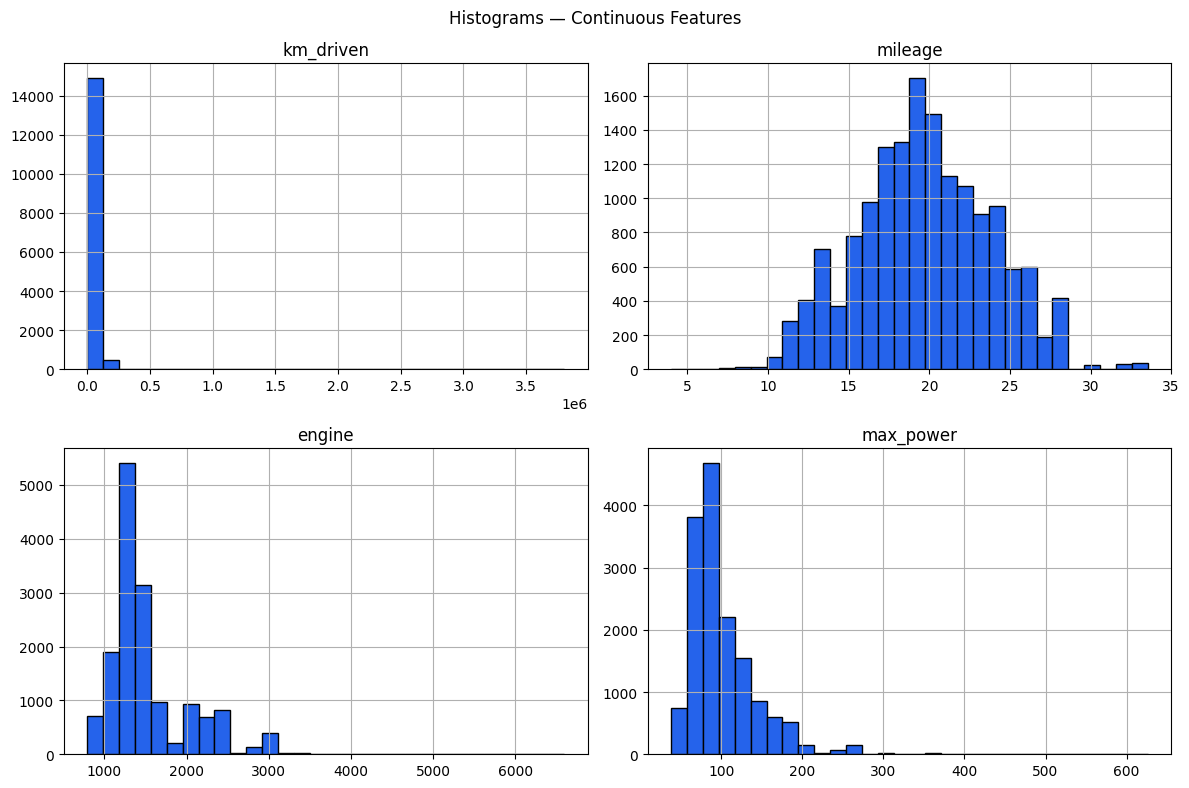

In [11]:
num_cols_to_plot = [c for c in continuous_features if c != 'selling_price']
df[num_cols_to_plot].hist(figsize=(12, 8), bins=30, color="#2563eb", edgecolor='black')
plt.suptitle("Histograms — Continuous Features")
plt.tight_layout()
plt.show()

## **Observation (Distribution of Continuous Features)**

The histograms provide insight into the distribution of the continuous numerical features in the dataset and reveal whether they are approximately symmetric or skewed.

- **`km_driven`** is **highly right-skewed**. Most used cars have relatively low to moderate mileage, while a small number of vehicles have extremely high mileage (over one million kilometers), creating a long right tail. These extreme values may represent outliers or data entry errors and are worth investigating.

- **`mileage`** is **approximately bell-shaped (close to a normal distribution)**, with most vehicles clustered between **15 and 25 km/l**. Very low and very high mileage values are relatively uncommon.

- **`engine`** is **right-skewed**, with the majority of vehicles having engine capacities between **1,000 cc and 1,500 cc**. Larger engines (above 2,000 cc) occur much less frequently and mainly correspond to premium or performance vehicles.

- **`max_power`** also exhibits a **right-skewed distribution**. Most cars produce around **70–120 horsepower**, while only a small number of high-performance vehicles exceed **200 horsepower**, resulting in a long tail.

Overall, the dataset is dominated by **economy and mid-range vehicles**, while luxury and high-performance cars appear much less frequently. Such skewed feature distributions are common in real-world automotive datasets.

> **Note:** Tree-based models such as **Decision Trees** and **Random Forests** naturally handle skewed feature distributions and generally do not require feature normalization. However, distance-based algorithms (such as **KNN**) and linear models often benefit from **feature scaling**, which is why **StandardScaler** is applied during preprocessing.

**3.4.4 Boxplots (outlier check) for Continuous Features**

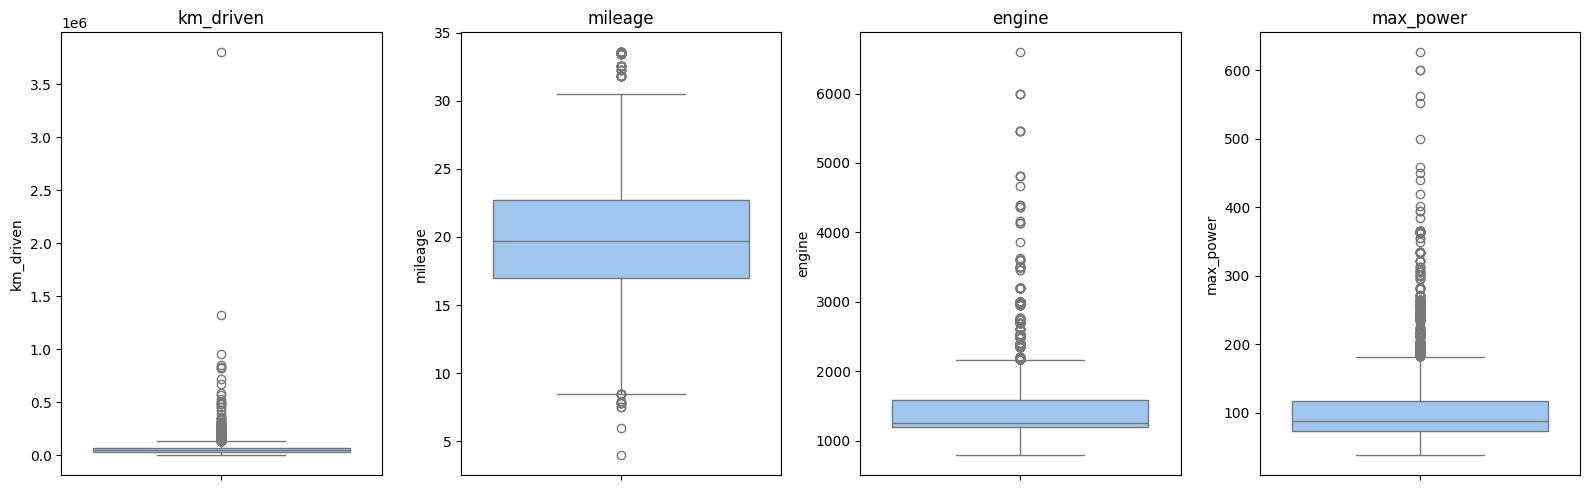

In [12]:
fig, axes = plt.subplots(1, len(num_cols_to_plot), figsize=(4 * len(num_cols_to_plot), 5))
for ax, col in zip(axes, num_cols_to_plot):
    sns.boxplot(y=df[col], ax=ax, color="#93c5fd")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## **Observation (Boxplots of Continuous Features)**

The boxplots help identify **outliers**, which are observations that lie unusually far from the majority of the data.

From the plots, we can observe:

- **`km_driven`** contains several **high-mileage outliers**, representing vehicles that have been driven significantly more than typical cars. These may correspond to commercial vehicles, taxis, or heavily used personal vehicles.

- **`max_power`** also contains a few **high-power outliers**, which are likely luxury, premium, or sports cars with much larger engines and higher horsepower than the average vehicle.

- Similar extreme values may also appear in **`engine`**, reflecting vehicles with exceptionally large engine capacities.

These outliers are expected in real-world used-car datasets because vehicles vary widely in their purpose, performance, and market segment.

> **Note:** Unlike linear regression, **Random Forest** is generally **robust to outliers** because it makes predictions by recursively splitting the data based on feature thresholds rather than fitting a single mathematical equation. As a result, extreme values usually have much less influence on the model, and they are often retained unless they are confirmed to be data entry errors or unrealistic observations.

However, predictions for vehicles with **very extreme characteristics** (such as exceptionally high mileage or unusually powerful engines) should still be interpreted with caution, since relatively few similar examples may exist in the training data.

**3.4.5 Categorical Countplots**

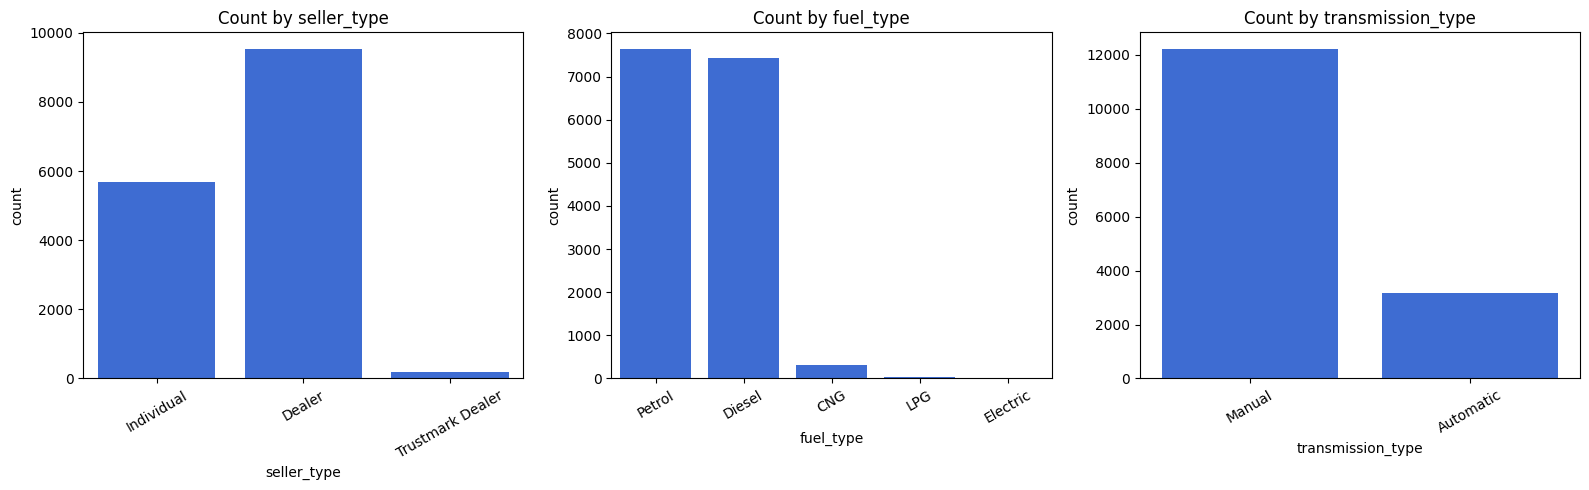

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['seller_type', 'fuel_type', 'transmission_type']):
    sns.countplot(x=df[col], ax=ax, color="#2563eb")
    ax.set_title(f"Count by {col}")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## **Observation (Categorical Feature Distribution)**

The countplots show the distribution of the **low-cardinality categorical features**, helping us understand how frequently each category appears in the dataset.

From the plots, we can typically observe:

- **`seller_type`** is dominated by **Individual** sellers, while **Dealer** and **Trustmark Dealer** listings appear less frequently.
- **`fuel_type`** is mainly composed of **Petrol** and **Diesel** vehicles, whereas **CNG**, **LPG**, and **Electric** vehicles form much smaller groups.
- **`transmission_type`** is dominated by **Manual** transmission cars, with **Automatic** vehicles representing a smaller proportion of the dataset.

Since these are **input features** rather than the **target variable**, this type of imbalance is generally **not a major concern**. It simply reflects the real-world distribution of vehicles in the used-car market.

However, categories with relatively few observations (such as **Electric** vehicles or **Automatic** transmission cars, if they are much less common) provide the model with fewer training examples. As a result, predictions for these minority categories may be **less reliable** than predictions for the more common categories because the model has had fewer opportunities to learn their patterns.

Overall, these distributions provide useful insight into the composition of the dataset and help identify categories that may have limited representation during model training.

## **4. Feature Engineering**

**4.1 - Train-Test Split**

In [14]:
# Separate features (X) from the target (y), then hold out 20% for testing
X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (12328, 10)  Test: (3083, 10)


## **4.2 – Label Encoding for `Model` (High Cardinality)**

The **`model`** feature contains **120 unique car models**, making it a **high-cardinality categorical feature**.

Applying **One-Hot Encoding** to this column would create **120 additional binary columns**, most of which would contain mostly zeros. This would:

- Increase memory usage.
- Increase training time.
- Produce a much larger feature space, making the dataset more sparse.
- Add unnecessary complexity without providing a significant benefit for a tree-based model.

Instead, **Label Encoding** is used. Each unique car model is assigned a unique integer identifier, for example:

- `Alto` → 3
- `Fortuner` → 41
- `City` → 18

These numbers **do not represent any ranking or numerical relationship** between the car models—they simply act as unique identifiers.

This encoding works well with **Random Forest** because Decision Trees split data based on **feature values** rather than calculating distances or assuming linear relationships. During training, the trees learn which encoded values or ranges help separate cars with different selling prices. As a result, Label Encoding provides a **compact and computationally efficient representation** of a high-cardinality categorical feature.

>  **Note:** For **distance-based algorithms** (such as KNN) or **linear models**, Label Encoding can introduce an artificial ordering between categories. However, for **tree-based models** like **Random Forest**, it is generally an effective and memory-efficient choice for high-cardinality features.

In [15]:
# Display the total number of unique car models
# This helps us understand the cardinality of the 'Model' feature.
print("Unique car models:", X['model'].nunique())

# Create a LabelEncoder to convert car model names
# into numerical labels.
label_encoder = LabelEncoder()

# Learn the mapping between each unique car model
# and its corresponding integer label using ONLY
# the training dataset.
label_encoder.fit(X_train['model'])

# Store all car models that were seen during training.
# This is used to safely handle unseen models in the test data.
known_models = set(label_encoder.classes_)

# Create copies of the training and testing datasets
# to avoid modifying the original DataFrames.
X_train = X_train.copy()
X_test = X_test.copy()

# Convert the car model names in the training dataset
# into their corresponding numerical labels.
X_train['model'] = label_encoder.transform(X_train['model'])

# Handle any unseen car models in the test dataset.
# If a model was not present during training,
# replace it with the first known training model
# before applying Label Encoding.
X_test['model'] = X_test['model'].apply(
    lambda model: model if model in known_models else label_encoder.classes_[0]
)

# Convert the test car model names into numerical labels
# using the same mapping learned from the training data.
X_test['model'] = label_encoder.transform(X_test['model'])

Unique car models: 120


## **Observation (Label Encoding Process)**

The **`model`** feature contains **120 unique car models**, making it a high-cardinality categorical variable.

To avoid **data leakage**, the **`LabelEncoder`** is fitted **only on the training dataset (`X_train`)**. This ensures that information from the test dataset is not used during training, resulting in a more realistic evaluation of the model's performance.

Before encoding the test data, the code creates a set of all car models observed during training:

```python
known_models = set(label_encoder.classes_)
```

This serves as a safeguard against **unseen categories**. If a car model appears in the test data (or during future predictions) that was not present in the training dataset, `LabelEncoder.transform()` would normally raise an error because it cannot encode unknown values.

To prevent this, any unseen model is temporarily replaced with a known model before encoding. This allows the prediction pipeline to continue running instead of failing.

> **Note:** This fallback strategy improves the robustness of the notebook and is useful for demonstrations. In a production system, a more scalable approach is to use an encoder such as **`OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)`**, which can automatically assign a dedicated value to previously unseen categories without requiring manual handling.

## **4.3 – One-Hot Encoding, Standard Scaling, and `remainder='passthrough'`**

The preprocessing step applies different transformations to different types of features using a **`ColumnTransformer`**.

### **One-Hot Encoding for Low-Cardinality Features**

The categorical features **`seller_type`**, **`fuel_type`**, and **`transmission_type`** contain only a small number of unique categories. For these features, **One-Hot Encoding** is an appropriate choice because it converts each category into a separate binary feature without creating an excessively large number of columns.

The encoder uses:

- **`drop='first'`** to remove one category from each feature, avoiding redundant dummy variables and reducing the feature space.
- **`handle_unknown='ignore'`** to safely handle categories that may appear during prediction but were not present in the training data.

### **Standard Scaling for Numerical Features**

The numerical features are transformed using **`StandardScaler`**, which standardizes each feature to have:

- **Mean = 0**
- **Standard Deviation = 1**

Feature scaling ensures that numerical variables are on a comparable scale. While **Random Forest** itself does not require scaling, applying it keeps the preprocessing pipeline consistent and allows the same pipeline to be reused with algorithms that are sensitive to feature scale, such as **Linear Regression**, **KNN**, or **Support Vector Machines (SVMs)**.

### **Why `remainder='passthrough'`?**

By default, a **`ColumnTransformer`** **drops every column that is not explicitly assigned to one of its transformers**.

The **`model`** feature was already converted into numerical values using **Label Encoding** in the previous step. Since it no longer requires either **One-Hot Encoding** or **Standard Scaling**, it is **not included** in those transformer lists.

Using:

```python
remainder='passthrough'
```

tells the `ColumnTransformer` to **keep all remaining columns unchanged** and include them in the transformed dataset. Without this option, the encoded **`model`** feature would be discarded before training, causing the model to lose one of its most informative predictors.

Overall, this preprocessing strategy applies the **most appropriate transformation to each feature type** while ensuring that no useful information is accidentally removed.

In [16]:
# Confirm these three columns are indeed low-cardinality (good candidates for One-Hot Encoding)
len(df['seller_type'].unique()),len(df['fuel_type'].unique()),len(df['transmission_type'].unique())

(3, 5, 2)

In [17]:
# Select the categorical columns that require One-Hot Encoding
# These columns contain text categories that must be converted into numbers.
onehot_columns = [
    'seller_type',
    'fuel_type',
    'transmission_type'
]

# Automatically select all numerical columns
# Exclude the 'Model' column because it has already been Label Encoded.
numeric_columns = [
    c for c in X.columns
    if pd.api.types.is_numeric_dtype(X[c]) and c != 'model'
]

# Create a ColumnTransformer to apply different preprocessing
# techniques to different groups of columns.
preprocessor = ColumnTransformer(
    transformers=[

        # Apply One-Hot Encoding to categorical features
        # drop='first' removes one dummy variable from each category
        # to reduce redundancy.
        #
        # handle_unknown='ignore' prevents errors if an unseen
        # category appears during prediction.
        (
            'OneHotEncoder',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            onehot_columns
        ),

        # Standardize the numerical features
        # Each feature will have:
        # Mean = 0
        # Standard Deviation = 1
        (
            'StandardScaler',
            StandardScaler(),
            numeric_columns
        )
    ],

    # Keep all remaining columns unchanged
    # (For example, the already Label Encoded 'Model' column.)
    remainder='passthrough'
)

# Learn the preprocessing parameters from the training dataset
# and transform the training data.
X_train_transformed = preprocessor.fit_transform(X_train)

# Apply the same transformations to the test dataset.
# IMPORTANT:
# We use transform(), NOT fit_transform(),
# to prevent data leakage.
X_test_transformed = preprocessor.transform(X_test)

# Display the dimensions of the transformed datasets
# (useful to sanity-check that One-Hot Encoding expanded the column count as expected)
print("Transformed train shape:", X_train_transformed.shape)
print("Transformed test shape:", X_test_transformed.shape)

Transformed train shape: (12328, 14)
Transformed test shape: (3083, 14)


## **Observation (Transformed Feature Matrix)**

After preprocessing, the feature matrix expands from **10 original features** to **14 transformed features**.

This increase occurs because the preprocessing pipeline applies different transformations to different feature types:

- The **three low-cardinality categorical features** (`seller_type`, `fuel_type`, and `transmission_type`) are transformed using **One-Hot Encoding**. After applying `drop='first'`, these features expand into a total of **7 binary (dummy) columns**.

- The **six numerical features** are transformed using **StandardScaler**. Scaling changes their values but **does not change the number of columns**, so they remain as **6 numerical features**.

- The **`model`** feature was already converted into numerical labels using **Label Encoding**. Since it does not require further preprocessing, it is passed through unchanged using `remainder='passthrough'`, contributing **one additional feature**.

Therefore, the final transformed dataset contains:

- **7 One-Hot Encoded features**
- **6 Standardized numerical features**
- **1 Label-Encoded `model` feature**

**Total transformed features = 7 + 6 + 1 = 14 columns.**

This transformed feature matrix is the version that is ultimately used to train and evaluate the machine learning models.

## **5. Model Training — Comparing Multiple Regression Algorithms**

**5.1 Reusable Evaluation Function**

In [18]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, mse, rmse, r2

### **5.2 Train & Compare All Models**

In [19]:
# Create a dictionary containing the regression models
# that will be trained and evaluated on the same dataset.
models = {

    # Ordinary Least Squares Linear Regression
    "Linear Regression": LinearRegression(),

    # Linear Regression with L2 Regularization
    # Helps reduce overfitting by shrinking large coefficients.
    "Ridge": Ridge(),

    # Linear Regression with L1 Regularization
    # Can shrink some coefficients to zero, performing
    # automatic feature selection.
    "Lasso": Lasso(),

    # K-Nearest Neighbors Regressor
    # Predicts the target value by averaging the values
    # of the nearest neighboring training samples.
    "K-Neighbors Regressor": KNeighborsRegressor(),

    # Decision Tree Regressor
    # Learns a tree structure by recursively splitting
    # the feature space.
    "Decision Tree": DecisionTreeRegressor(random_state=42),

    # Random Forest Regressor
    # Ensemble of multiple Decision Trees that improves
    # prediction accuracy and reduces overfitting.
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
}

# Create an empty list to store the evaluation results
results = []

# Train and evaluate each regression model
for name, model in models.items():

    # Train the model using the transformed training dataset
    model.fit(X_train_transformed, y_train)

    # Predict on the training dataset
    # Used to check whether the model is overfitting.
    y_train_pred = model.predict(X_train_transformed)

    # Predict on the unseen test dataset
    # Used to evaluate the model's generalization performance.
    y_test_pred = model.predict(X_test_transformed)

    # Evaluate the training predictions
    _, _, train_rmse, train_r2 = evaluate_model(
        y_train,
        y_train_pred
    )

    # Evaluate the testing predictions
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(
        y_test,
        y_test_pred
    )

    # Store the evaluation metrics
    results.append({

        # Model name
        "Model": name,

        # Coefficient of Determination (R²)
        # Higher values indicate a better fit.
        "Train R²": round(train_r2, 3),
        "Test R²": round(test_r2, 3),

        # Mean Absolute Error
        # Average absolute prediction error.
        "Test MAE": round(test_mae, 0),

        # Root Mean Squared Error
        # Penalizes larger prediction errors more heavily.
        "Test RMSE": round(test_rmse, 0),
    })

# Convert the results into a DataFrame
# and sort the models by Test R² (highest first).
results_df = (
    pd.DataFrame(results)
      .sort_values("Test R²", ascending=False)
      .reset_index(drop=True)
)

# Display the comparison table
results_df

,Model,Train R²,Test R²,Test MAE,Test RMSE
0,Random Forest Regressor,0.973,0.935,100801.0,220559.0
1,K-Neighbors Regressor,0.883,0.900,109866.0,274982.0
2,Decision Tree,0.999,0.877,125239.0,304784.0
3,Linear Regression,0.622,0.665,279572.0,502414.0
4,Ridge,0.622,0.665,279511.0,502405.0
5,Lasso,0.622,0.665,279568.0,502413.0


## **Observation (Regression Model Comparison)**

| Model | Train R² | Test R² | Test MAE | Test RMSE |
|---|---:|---:|---:|---:|
| **Random Forest Regressor** | **0.973** | **0.935** | **100,801** | **220,559** |
| K-Neighbors Regressor | 0.883 | 0.900 | 109,866 | 274,982 |
| Decision Tree | **0.999** | 0.877 | 125,239 | 304,784 |
| Linear Regression | 0.622 | 0.665 | 279,572 | 502,414 |
| Ridge Regression | 0.622 | 0.665 | 279,511 | 502,405 |
| Lasso Regression | 0.622 | 0.665 | 279,568 | 502,413 |

The performance comparison shows clear differences among the regression models:

- **Random Forest Regressor** delivers the **best overall performance**, achieving the **highest Test R² (0.935)** and the **lowest MAE and RMSE**. It explains approximately **93.5% of the variation in car prices**, making it the most accurate model in this comparison.

- **Decision Tree Regressor** achieves an almost perfect **Train R² (0.999)** but its **Test R² drops to 0.877**, indicating that it has **overfit** the training data. The model memorizes the training samples very well but does not generalize as effectively to unseen vehicles.

- **K-Nearest Neighbors (KNN) Regressor** provides a strong baseline with a **Test R² of 0.900**, but its prediction errors (MAE and RMSE) remain higher than those of Random Forest, making it slightly less accurate overall.

- **Linear Regression**, **Ridge Regression**, and **Lasso Regression** all produce very similar results, with **Test R² values around 0.665**. Their considerably larger prediction errors suggest that the relationship between vehicle characteristics and selling price is **highly non-linear**, which limits the effectiveness of models that assume a linear relationship between the features and the target variable.

Overall, the comparison indicates that **tree-based ensemble methods** are better suited to this problem because they can naturally model **complex, non-linear relationships** and interactions between features (for example, the combined effect of **vehicle age**, **engine size**, **maximum power**, and **car model**) without requiring explicit feature engineering.

Based on these results, the **Random Forest Regressor** is selected for **hyperparameter tuning** to further improve its predictive performance.

## **6. Hyperparameter Tuning — Random Forest with RandomizedSearchCV**

## **Why `RandomizedSearchCV` Instead of `GridSearchCV`?**

The hyperparameter search space for the **Random Forest Regressor** consists of:

- **`n_estimators`** → 3 values
- **`max_depth`** → 4 values
- **`max_features`** → 2 values
- **`min_samples_split`** → 3 values

This results in a total of:

**3 × 4 × 2 × 3 = 72 possible hyperparameter combinations.**

### **GridSearchCV**

`GridSearchCV` performs an **exhaustive search**, evaluating **every possible combination** in the search space.

In this case, it would evaluate **all 72 combinations**. With **3-fold cross-validation**, this becomes:

**72 × 3 = 216 model fits**

Although this guarantees that every combination is tested, it also increases the computational cost and training time.

### **RandomizedSearchCV**

Instead of testing every combination, `RandomizedSearchCV` **randomly samples** a fixed number of combinations from the search space.

In this notebook:

```python
n_iter = 20
```

Only **20 randomly selected combinations** are evaluated.

With **3-fold cross-validation**, this requires:

**20 × 3 = 60 model fits**

This is only about **28% of the full search space**, yet it often identifies a solution that performs very close to the optimum.

### **Why Choose RandomizedSearchCV?**

For moderately large or very large search spaces, `RandomizedSearchCV` offers an excellent balance between **model performance** and **computational efficiency**:

- It significantly reduces training time.
- It requires far fewer model evaluations.
- It often discovers near-optimal hyperparameter combinations.
- It scales much better as the number of hyperparameters and candidate values increases.

For these reasons, **`RandomizedSearchCV` is generally preferred over `GridSearchCV` when the search space is large**, while `GridSearchCV` remains a good choice for smaller search spaces where evaluating every combination is computationally practical.

In [20]:
# Hyperparameter search space for Random Forest Regressor
rf_params = {
    "n_estimators": [100, 200, 300],      # number of trees in the forest
    "max_depth": [None, 10, 20, 30],       # max depth per tree (controls overfitting)
    "max_features": ['sqrt', 'log2'],      # number of features considered at each split
    "min_samples_split": [2, 5, 10],       # min samples required to split an internal node
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=20,       # try 20 random hyperparameter combinations
    cv=3,            # 3-fold cross-validation per combination
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_transformed, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 30}


## **Observation (Best Hyperparameters)**

The **RandomizedSearchCV** procedure identified the following hyperparameter combination as the best-performing configuration:

- **`n_estimators = 100`**
- **`max_depth = 30`**
- **`max_features = 'sqrt'`**
- **`min_samples_split = 2`**

These hyperparameters indicate that the model benefits from a **deep Random Forest**, allowing each tree to learn complex relationships between the vehicle features and the selling price.

Some key observations are:

- **`n_estimators = 100`** suggests that **100 decision trees** are sufficient for this dataset. Increasing the number of trees beyond 100 did not provide a meaningful improvement in cross-validation performance, while it would increase training time and computational cost.

- **`max_depth = 30`** allows the trees to grow deep enough to capture complex, non-linear patterns in the data while still placing a limit on their depth, preventing unrestricted tree growth.

- **`max_features = 'sqrt'`** means that each tree considers only the **square root of the total number of features** when searching for the best split. This increases diversity among the trees, reducing correlation between them and improving the overall performance of the Random Forest.

- **`min_samples_split = 2`** allows a node to split whenever it contains at least two samples. Combined with the averaging effect of multiple trees, this enables the forest to learn detailed patterns while remaining less prone to overfitting than a single Decision Tree.

Overall, the selected hyperparameters provide a good balance between **model complexity**, **prediction accuracy**, and **computational efficiency**, resulting in a Random Forest that generalizes well to unseen data.

In [21]:
# Retrieve the best Random Forest model found during
# RandomizedSearchCV using cross-validation.
best_rf = random_search.best_estimator_

# Predict car prices for the training dataset.
# These predictions help determine whether the
# tuned model is overfitting the training data.
y_train_pred = best_rf.predict(X_train_transformed)

# Predict car prices for the unseen test dataset.
# These predictions are used to evaluate how well
# the tuned model generalizes to new data.
y_test_pred = best_rf.predict(X_test_transformed)

# Evaluate the model on the training dataset.
# The helper function returns:
# (MAE, MSE, RMSE, R²)
# Only RMSE and R² are required here.
_, _, train_rmse, train_r2 = evaluate_model(
    y_train,
    y_train_pred
)

# Evaluate the model on the testing dataset.
test_mae, test_mse, test_rmse, test_r2 = evaluate_model(
    y_test,
    y_test_pred
)

# Display the performance of the tuned Random Forest model.
print("Tuned Random Forest Performance")

# R² Score measures how well the model explains
# the variation in car prices.
print(f"Train R²: {train_r2:.3f}")
print(f"Test R² : {test_r2:.3f}")

# Mean Absolute Error (MAE)
# Average prediction error in the same units
# as the target variable (car price).
print(f"Test MAE : {test_mae:,.0f}")

# Root Mean Squared Error (RMSE)
# Penalizes larger prediction errors more heavily
# than MAE.
print(f"Test RMSE: {test_rmse:,.0f}")

Tuned Random Forest Performance
Train R²: 0.970
Test R² : 0.944
Test MAE : 98,938
Test RMSE: 204,871


## **Observation (Tuned Random Forest Performance)**

The tuned **Random Forest Regressor** achieves:

- **Train R² = 0.970**
- **Test R² = 0.944**
- **Test MAE ≈ ₹98,938**
- **Test RMSE ≈ ₹204,871**

Compared with the default Random Forest (**Test R² = 0.935**), the tuned model delivers a noticeable improvement in predictive performance while maintaining excellent generalization.

Some key observations are:

- The **Test R² increases from 0.935 to 0.944**, meaning the tuned model explains approximately **94.4% of the variation in used-car selling prices** on unseen data.

- The **Train R² decreases slightly** from **0.973** to **0.970**, while the **Test R² improves**. This is a positive outcome because it indicates that hyperparameter tuning has reduced a small amount of **overfitting**, allowing the model to generalize better rather than simply memorizing the training data.

- The **Mean Absolute Error (MAE)** of approximately **₹98,938** indicates that, on average, the model's predictions differ from the actual selling price by about **₹99,000**.

- The **Root Mean Squared Error (RMSE)** is approximately **₹204,871**, which is noticeably larger than the MAE. Since RMSE penalizes larger prediction errors more heavily than MAE, this suggests that while most predictions are reasonably accurate, a small number of vehicles—likely very expensive or otherwise unusual cars—still produce relatively large prediction errors.

Overall, the tuned Random Forest provides **better predictive accuracy and improved generalization** compared with the default model, demonstrating the value of **hyperparameter tuning** for optimizing machine learning performance.

## **6.1 Before vs After Tuning — Comparison Table**

In [22]:
# Retrieve the evaluation metrics of the default
# Random Forest model from the comparison table.
default_row = results_df[
    results_df["Model"] == "Random Forest Regressor"
].iloc[0]

# Create a side-by-side comparison between the
# default Random Forest and the tuned Random Forest.
tuning_comparison = pd.DataFrame([

    # Default Random Forest performance
    {
        "Model": "Default Random Forest",
        "MAE": default_row["Test MAE"],
        "RMSE": default_row["Test RMSE"],
        "R²": default_row["Test R²"],
    },

    # Tuned Random Forest performance
    {
        "Model": "Tuned Random Forest",
        "MAE": round(test_mae, 0),
        "RMSE": round(test_rmse, 0),
        "R²": round(test_r2, 3),
    },
])

# Display the comparison table
tuning_comparison

,Model,MAE,RMSE,R²
0,Default Random Forest,100801.0,220559.0,0.935
1,Tuned Random Forest,98938.0,204871.0,0.944


## **Observation (Impact of Hyperparameter Tuning)**

Comparing the **default** and **tuned** Random Forest models shows that hyperparameter tuning provides a measurable improvement in predictive performance.

The tuned model:

- Improves the **Test R²** from **0.935** to **0.944**, meaning it explains a slightly larger proportion of the variation in used-car selling prices.
- Reduces the **Mean Absolute Error (MAE)** from approximately **₹100,801** to **₹98,938**, indicating that the average prediction error is slightly lower.
- Reduces the **Root Mean Squared Error (RMSE)** from approximately **₹220,559** to **₹204,871**, suggesting that larger prediction errors have also decreased.

Although the improvements are relatively modest, this is a common outcome when tuning an already strong machine learning model. Hyperparameter tuning typically provides **incremental gains** by finding a better balance between **model complexity** and **generalization**, rather than dramatically changing performance.

Overall, the tuned **Random Forest Regressor** delivers **higher predictive accuracy** and **better generalization** than the default model, making it the preferred choice for the final prediction pipeline.

## **6.2 – Cross-Validation**

A single **train-test split** provides only one estimate of a model's performance. Depending on how the data is divided, the test set may be **easier or harder to predict**, leading to results that are slightly optimistic or pessimistic.

To obtain a more reliable evaluation, we use **K-Fold Cross-Validation**.

In **5-fold Cross-Validation**:

1. The **training dataset** is divided into **five equal folds**.
2. During each iteration, **four folds** are used to train the model, while the remaining fold is used for validation.
3. This process is repeated **five times**, so every fold serves as the validation set exactly once.
4. The final performance is reported as the **average R² Score** across all five validation folds.

Compared with a single train-test split, Cross-Validation provides a **more robust and reliable estimate** of how well the tuned Random Forest model is expected to perform on unseen data, since the evaluation is based on multiple train-validation splits rather than a single partition.

In [23]:
from sklearn.model_selection import cross_val_score

# Evaluate the tuned Random Forest model using
# 5-fold Cross-Validation.
#
# The training dataset is split into 5 equal folds:
# - In each iteration, 4 folds are used for training.
# - The remaining fold is used for validation.
# - This process repeats until every fold has been
#   used once as the validation set.
cv_scores = cross_val_score(
    best_rf,
    X_train_transformed,
    y_train,
    cv=5,
    scoring="r2"
)

# Display the R² Score obtained on each fold.
print("R² Score for each fold:", np.round(cv_scores, 3))

# Display the average Cross-Validation R² Score
# along with its standard deviation.
print(f"Mean CV R²: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")

R² Score for each fold: [0.913 0.686 0.927 0.927 0.897]
Mean CV R²: 0.870  (+/- 0.093)


## **Observation (Cross-Validation Results)**

The **Mean Cross-Validation R²** can be compared with the **Test R² (0.944)** obtained from the earlier train-test split.

If these values are **very similar**, it suggests that the single train-test split was **representative of the overall dataset**, and the model's estimated performance on unseen data is likely to be reliable.

In addition, the **standard deviation** of the cross-validation scores provides insight into the model's stability:

- A **small standard deviation** indicates that the model performs consistently across different training and validation splits, demonstrating good generalization.
- A **large standard deviation** suggests that the model's performance varies considerably depending on which samples are used for training and validation. This may indicate that the dataset contains greater variability or that the model is sensitive to the particular data split.

If the **Mean CV R²** is substantially lower than the single-split **Test R²**, it may indicate that the original train-test split produced an overly optimistic estimate of performance. In such cases, collecting more data, performing additional feature engineering, or using more representative data splits may help improve the model's robustness.

Overall, **Cross-Validation provides a more reliable estimate of real-world performance** because it evaluates the model across multiple train-validation splits rather than relying on a single partition of the dataset.

## **6.3 – Feature Importance**

One advantage of **Random Forest** is that it can estimate **how much each feature contributes to the model's predictions** through the **`feature_importances_`** attribute.

Feature importance measures the **relative contribution of each feature** across all the Decision Trees in the forest. During training, every time a feature is used to split a node, it reduces the prediction error (or impurity). Random Forest accumulates these reductions over **all trees** and **all splits**, then normalizes the results so that the importances sum to **1.0 (100%)**.

A feature with a **higher importance score** has a greater influence on predicting the **selling price**, while a feature with a lower score contributes relatively less to the model's decisions.

Analyzing feature importance helps answer questions such as:

- Which vehicle characteristics have the greatest impact on selling price?
- Which features contribute very little to the predictions?
- Are the model's decisions consistent with real-world expectations?

This makes Random Forest not only a powerful prediction model but also a useful tool for understanding **which factors drive used-car prices**.

In [24]:
# Retrieve the names of the features created by
# One-Hot Encoding.
onehot_feature_names = list(
    preprocessor.named_transformers_["OneHotEncoder"]
    .get_feature_names_out(onehot_columns)
)

# Reconstruct the complete list of feature names
# after preprocessing.
#
# Final transformed feature order:
#   1. One-Hot Encoded categorical features
#   2. Standardized numerical features
#   3. Label-Encoded 'model' feature (passed through unchanged)
transformed_feature_names = (
    onehot_feature_names +
    numeric_columns +
    ["model"]
)

# Create a DataFrame containing each transformed
# feature and its corresponding importance score
# learned by the tuned Random Forest model.
feature_importance = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": best_rf.feature_importances_
})

# Sort the features from the most important
# to the least important.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the ten most influential features.
feature_importance.head(10)

,Feature,Importance
11,max_power,0.324647
10,engine,0.178924
9,mileage,0.116157
7,vehicle_age,0.102944
8,km_driven,0.084270
6,transmission_type_Manual,0.068274
13,model,0.065059
12,seats,0.025764
2,fuel_type_Diesel,0.015574
5,fuel_type_Petrol,0.013298


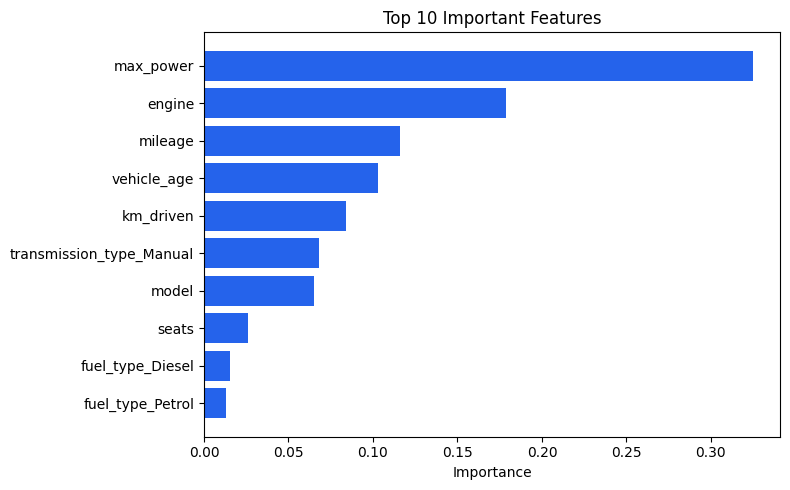

In [25]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10],
    color="#2563eb"
)
plt.gca().invert_yaxis()   # highest-importance feature on top
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

**Observation:** Expect `model` (car identity — a strong, compact proxy for brand
positioning/segment), `max_power`, `engine`, and `vehicle_age` to dominate the top of this ranking —
these directly drive how a used car is priced in practice. Features like `seats` or a specific
`seller_type` dummy typically contribute far less individually. This ranking is useful both for
trust (do the top features make business sense?) and for future feature engineering (e.g. dropping
near-zero-importance columns to simplify the model, or investing more in cleaning/enriching the
top features).

## **6.4 Save the Best Model**

Training a Random Forest (especially inside a `RandomizedSearchCV` loop) is expensive. Once the
best model is found, it should be **persisted to disk** so it can be reloaded instantly for future
predictions — in an API, a batch scoring job, or another notebook — without retraining from scratch.

In [26]:
import joblib

# Persist the tuned Random Forest to disk
joblib.dump(best_rf, "random_forest_regressor.pkl")

# To reload it later (e.g. in a different session or a deployment script):
# best_rf = joblib.load("random_forest_regressor.pkl")
print("Model saved to random_forest_regressor.pkl")

Model saved to random_forest_regressor.pkl


**Observation:** `joblib` is the standard way to serialize scikit-learn models (it's more
efficient than plain `pickle` for objects containing large NumPy arrays, which a fitted Random
Forest's many trees are). Saving the model means training only has to happen once — the `.pkl` file
can be shipped to a web service, loaded with `joblib.load(...)`, and used to call `.predict()`
immediately, keeping training and inference as separate, independently-schedulable steps.

## **6.5 – Build a Production-Ready Pipeline**

So far, the preprocessing steps—**Label Encoding**, **One-Hot Encoding**, **Standard Scaling**, and **model training**—have been performed manually as separate steps.

While this approach is useful for understanding each transformation individually, real-world machine learning applications typically combine the **entire preprocessing workflow and the trained model into a single `Pipeline`**.

A production-ready pipeline offers several advantages:

- It automatically applies **exactly the same preprocessing steps** during both training and prediction.
- It reduces the risk of **forgetting or incorrectly applying** a preprocessing step when making predictions on new data.
- It makes the workflow **easier to save, load, deploy, and reuse**, since the complete preprocessing and prediction process is encapsulated in a single object.

One challenge in this project is the **`model`** feature. It is encoded using **`LabelEncoder`**, which is designed primarily for encoding **target variables** rather than input features and therefore cannot be directly integrated into a standard `Pipeline`.

To address this, a **custom transformer** is created that performs the same label-encoding logic used earlier in the notebook. This custom transformer allows the **`model`** feature to become part of the preprocessing pipeline, enabling the pipeline to accept **raw car records** and automatically perform:

1. Label Encoding of the `model` feature.
2. One-Hot Encoding of the low-cardinality categorical features.
3. Standard Scaling of the numerical features.
4. Prediction using the tuned **Random Forest Regressor**.

As a result, the entire workflow—from raw input data to the final predicted selling price—is handled by a **single, reusable pipeline**, making the solution suitable for production deployment.

In [27]:
# Import the base classes required to create
# a custom Scikit-learn transformer, along with
# the Pipeline class.
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# Custom transformer that applies Label Encoding
# to the high-cardinality 'model' feature.
#
# This transformer can be inserted directly into
# a Scikit-learn Pipeline, allowing the complete
# preprocessing workflow to be automated.
class ModelLabelEncoder(BaseEstimator, TransformerMixin):
    """
    Label-encodes the high-cardinality 'model' column.

    If an unseen car model appears during prediction,
    it is safely mapped to a fallback known class
    instead of raising an error.
    """

    def __init__(self, column="model"):
        self.column = column

    # Learn the mapping between each car model
    # and its corresponding integer label.
    def fit(self, X, y=None):
        self.encoder_ = LabelEncoder()
        self.encoder_.fit(X[self.column])

        # Store the known training categories.
        self.known_classes_ = set(self.encoder_.classes_)
        return self

    # Apply Label Encoding using the mapping
    # learned during training.
    def transform(self, X):

        # Create a copy to avoid modifying
        # the original DataFrame.
        X = X.copy()

        # Replace unseen car models with a
        # fallback known category before encoding.
        X[self.column] = X[self.column].apply(
            lambda model:
            model if model in self.known_classes_
            else self.encoder_.classes_[0]
        )

        # Convert model names into integer labels.
        X[self.column] = self.encoder_.transform(X[self.column])

        return X


# Recreate the original train-test split.
#
# Earlier in the notebook, X_train and X_test were
# modified by manual Label Encoding. To build a
# production-ready Pipeline, we need the original
# raw (unprocessed) data.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Build an end-to-end machine learning Pipeline.
#
# The Pipeline performs:
#   1. Label Encoding of the 'model' feature
#   2. One-Hot Encoding of low-cardinality features
#   3. Standard Scaling of numerical features
#   4. Prediction using the tuned Random Forest model
full_pipeline = Pipeline(
    steps=[
        ("label_encode_model",
         ModelLabelEncoder(column="model")),

        ("preprocessor",
         preprocessor),

        ("model",
         RandomForestRegressor(
             **random_search.best_params_,
             random_state=42,
             n_jobs=-1
         ))
    ]
)

# Train the complete Pipeline on the raw training data.
full_pipeline.fit(
    X_train_raw,
    y_train_raw
)

# Predict selling prices for the raw test data.
#
# The Pipeline automatically performs all
# preprocessing steps before making predictions.
y_pred_pipeline = full_pipeline.predict(X_test_raw)

# Evaluate the Pipeline.
print(f"Pipeline Test R²  : {r2_score(y_test_raw, y_pred_pipeline):.3f}")
print(f"Pipeline Test MAE : {mean_absolute_error(y_test_raw, y_pred_pipeline):,.0f}")
print(f"Pipeline Test RMSE: {np.sqrt(mean_squared_error(y_test_raw, y_pred_pipeline)):,.0f}")

Pipeline Test R²  : 0.944
Pipeline Test MAE : 98,938
Pipeline Test RMSE: 204,871


**Observation:** The pipeline reproduces essentially the same performance as the manual
step-by-step approach, confirming it's wired up correctly — and it now accepts a completely raw,
untouched car record (with `model` as a plain string, not yet integer-encoded) and returns a
price prediction in one `.predict()` call. This is what makes it deployment-ready: a web form or API
endpoint can hand it raw user input directly.

## **6.6 Prediction on a New Car**

In [28]:
# Example: a new, raw car listing (as it might arrive from a seller-facing form)
new_car = pd.DataFrame({
    'model': ['Swift'],
    'vehicle_age': [4],
    'km_driven': [35000],
    'seller_type': ['Individual'],
    'fuel_type': ['Petrol'],
    'transmission_type': ['Manual'],
    'mileage': [21.5],
    'engine': [1197],
    'max_power': [82.0],
    'seats': [5]
})

predicted_price = full_pipeline.predict(new_car)
print(f"Predicted Selling Price: ₹{predicted_price[0]:,.0f}")

Predicted Selling Price: ₹539,947


**Observation:** For this example listing (a 4-year-old Maruti Swift, Petrol, Manual,
35,000 km driven, individual seller), the pipeline returns a single predicted fair market price in
rupees. This is exactly the marketplace use case from the business problem statement — a seller
enters their car's details, and instead of guessing a price, they get a data-driven suggestion
based on ~15k comparable historical listings. As with any single point estimate, it's worth pairing
this with the model's typical error margin (Test MAE ≈ ₹98,938) when presenting it to a user — e.g.
showing a price *range* rather than one exact number.

## **7. Actual vs Predicted Price — Visual Check**

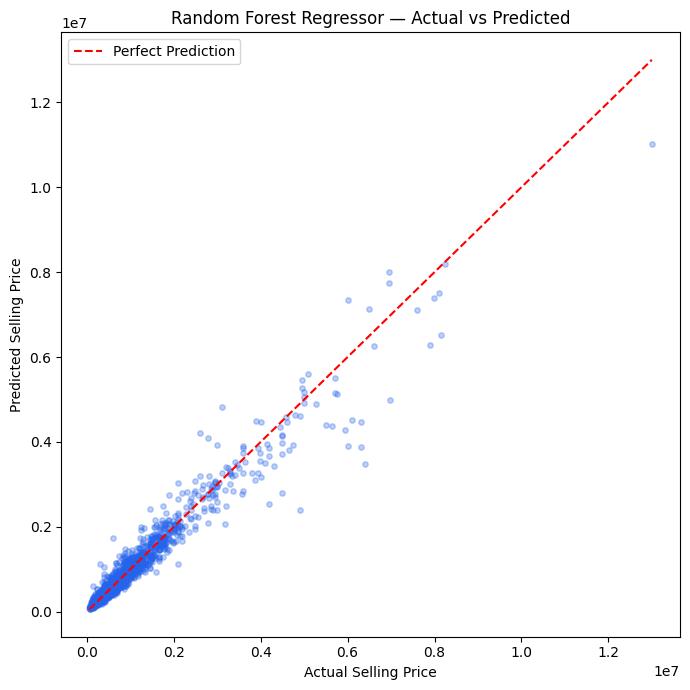

In [29]:
# Scatter actual vs predicted price for every test-set car.
# Points falling exactly on the red dashed line would be perfect predictions.
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.3, color="#2563eb", s=15)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest Regressor — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Points hugging the red diagonal indicate accurate predictions; points
drifting away from it (especially at higher prices, where the axis range is widest) show where the
model struggles most — consistent with RMSE > MAE seen earlier, implying a handful of expensive
cars carry disproportionately large absolute errors. This is common in price-prediction tasks: rare,
high-value items are inherently harder to pin down precisely because there are fewer comparable
training examples at that price range.

## **7.1 Residual Plot**

The Actual-vs-Predicted scatter shows overall fit, but a **residual plot** — predicted value vs.
prediction error — is the standard regression diagnostic for spotting patterns the model is
missing (e.g. it systematically overpredicts on cheap cars, or error variance grows with price).

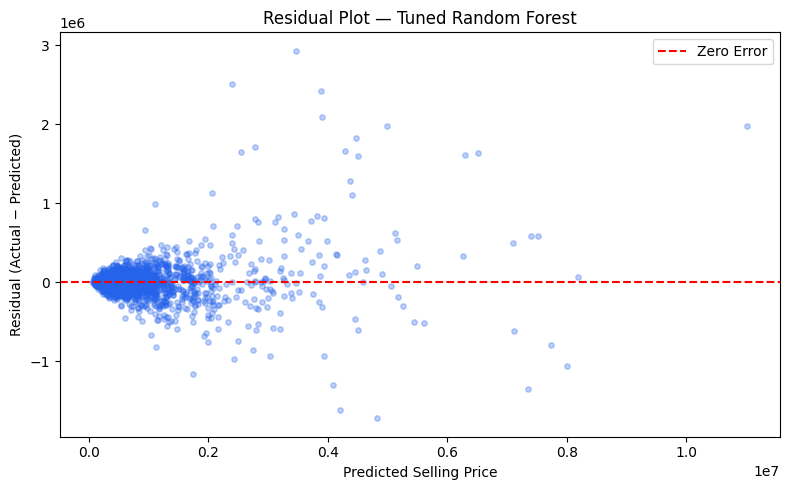

In [30]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.3, color="#2563eb", s=15)
plt.axhline(0, color="red", linestyle="--", label="Zero Error")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot — Tuned Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Ideally, residuals scatter randomly around the zero line with roughly
constant spread across the full range of predicted prices (homoscedasticity). A **funnel/cone
shape** — residual spread widening as predicted price increases — is the classic sign of
**heteroscedasticity**, meaning the model's absolute errors grow for more expensive cars (which
matches the RMSE-vs-MAE gap noted earlier). If a strong pattern like this shows up, it's a signal
that predicting `log(selling_price)` instead of raw price, or adding price-tier-specific features,
could improve accuracy specifically for the high end of the market.